In [1]:
import numpy as np
from scipy.linalg import eigh
from scipy.special import kv, gamma
import matplotlib.pyplot as plt
import matplotlib as mpl
from cycler import cycler

In [2]:
# function definitions
def squared_exponential_kernel(x, y, sigma=1.0, ell=0.2):
    x = np.atleast_2d(x)
    y = np.atleast_2d(y)

    d2 = np.sum((x[:, None, :] - y[None, :, :])**2, axis=-1)
    return sigma**2 * np.exp(-0.5 * d2 / ell**2)


def matern_kernel(x, y, sigma=1.0, ell=0.2, nu=1.5):
    x = np.atleast_2d(x)
    y = np.atleast_2d(y)
    r = np.sqrt(np.sum((x[:, None, :] - y[None, :, :])**2, axis=-1))
    z = np.sqrt(2 * nu) * r / ell
    K = np.zeros_like(z)
    nonzero = z > 0

    K[nonzero] = (
        sigma**2
        * (2 ** (1 - nu) / gamma(nu))
        * (z[nonzero] ** nu)
        * kv(nu, z[nonzero])
    )

    K[~nonzero] = sigma**2
    return K


def kl_expansion(
    x,
    y=None,
    n_terms=10,
    kernel="se",
    sigma=1.0,
    ell=0.2,
    nu=1.5,
    jitter=1e-10,
):
    """
    Truncated KL expansion for a GP covariance kernel.

    Parameters
    ----------
    x : array, shape (n, d)
        Points used to construct the KL basis.
    y : array, shape (m, d), optional
        Points where the KL modes are evaluated. If None, y=x.
    n_terms : int
        Number of KL terms to keep.
    kernel : {"se", "matern"}
        Kernel type.
    sigma : float
        Marginal standard deviation.
    ell : float
        Length scale.
    nu : float
        Smoothness parameter for Matérn kernel.
    jitter : float
        Small diagonal stabilization.

    Returns
    -------
    lambdas : array, shape (n_terms,)
        KL eigenvalues.
    phi_y : array, shape (m, n_terms)
        KL eigenfunctions evaluated at y.
    sample_fn : callable
        Function generating one random KL sample at y.
    """

    x = np.atleast_2d(x)
    if y is None:
        y = x
    else:
        y = np.atleast_2d(y)

    if kernel == "se":
        Kxx = squared_exponential_kernel(x, x, sigma, ell)
        Kyx = squared_exponential_kernel(y, x, sigma, ell)
    elif kernel == "matern":
        Kxx = matern_kernel(x, x, sigma, ell, nu)
        Kyx = matern_kernel(y, x, sigma, ell, nu)
    else:
        raise ValueError("kernel must be 'se' or 'matern'")

    n = x.shape[0]
    Kxx = Kxx + jitter * np.eye(n)
    eigvals, eigvecs = eigh(Kxx)
    idx = np.argsort(eigvals)[::-1]

    eigvals = eigvals[idx][:n_terms]
    eigvecs = eigvecs[:, idx][:, :n_terms]

    # Nyström extension to evaluate eigenfunctions at y
    phi_y = Kyx @ eigvecs / eigvals

    def sample_fn(coeffs=None):
        if coeffs is None:
            coeffs = np.random.randn(n_terms)

        return phi_y @ (np.sqrt(eigvals) * coeffs)

    return eigvals, phi_y, sample_fn


msample is (10000,) and ssample is (10000,)


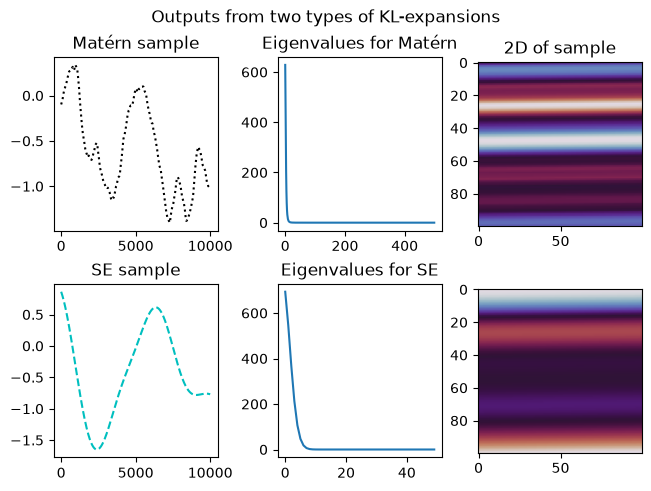

In [3]:
sample_num = 100
x = np.linspace(0, 1, 2000)[:, None]
y = np.linspace(0, 1, sample_num**2)[:, None]

mlambdas, mphi_y, msample = kl_expansion(
    x,
    y,
    n_terms=500,
    kernel="matern",
    sigma=1.0,
    ell=0.15,
    nu=1.5,
)

# um = sample()

slambdas, sphi_y, ssample = kl_expansion(
    x,
    y,
    n_terms=50,
    kernel="se",
    sigma=1.0,
    ell=0.15,
)

# us = sample()
# u(y) ≈ sum_j sqrt(lambda_j) * xi_j * phi_j(y)
print("msample is " + str(msample().shape) + " and ssample is " + str(ssample().shape))
ms = msample().reshape(sample_num,sample_num)
ses = ssample().reshape(sample_num,sample_num)
    

# Plot the results

fig,axs = plt.subplots(2, 3, layout='constrained')
fig.suptitle('Outputs from two types of KL-expansions')
axs[0,0].plot(msample(),'k:')
axs[0,0].set_title('Matérn sample')
axs[0,1].plot(mlambdas)
axs[0,1].set_title('Eigenvalues for Matérn')
axs[0,2].imshow(ms,cmap='twilight')
axs[0,2].set_title('2D of sample')
axs[1,0].plot(ssample(),'c--')
axs[1,0].set_title('SE sample')
axs[1,1].plot(slambdas)
axs[1,1].set_title('Eigenvalues for SE')
axs[1,2].imshow(ses, cmap='twilight')
plt.show()

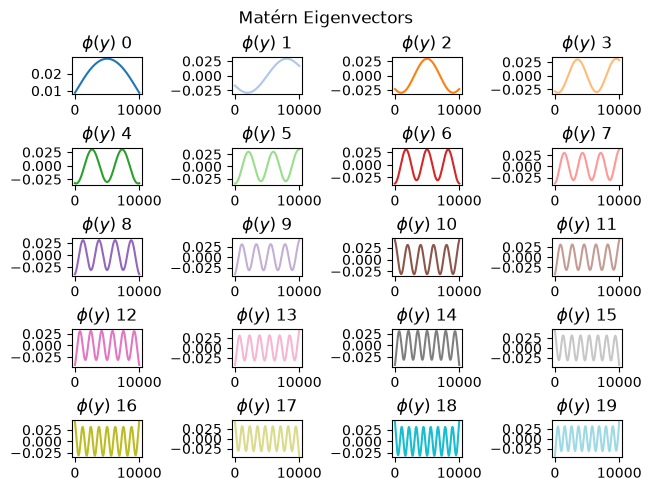

In [4]:
fig,axs = plt.subplots(5, 4, layout='constrained')
fig.suptitle('Matérn Eigenvectors')
for i,ax in enumerate(axs.flat):
    ax.plot(mphi_y[:,i], color=mpl.color_sequences['tab20'][i%20])
    ax.set_title(f'$\phi(y)$ {i}')
plt.show()

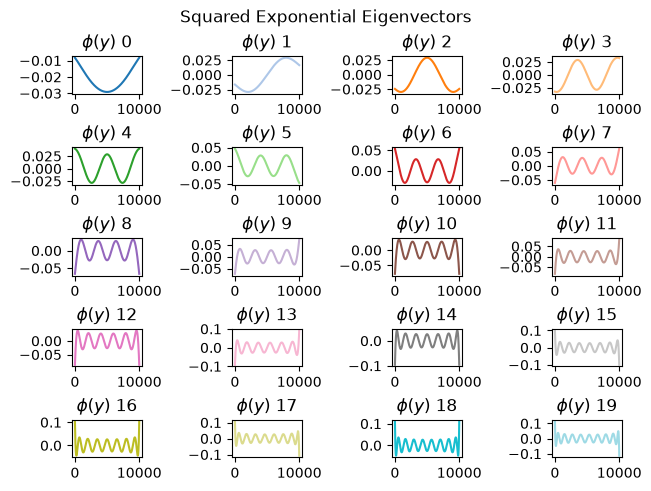

In [5]:
fig,axs = plt.subplots(5, 4, layout='constrained')
fig.suptitle('Squared Exponential Eigenvectors')
for i,ax in enumerate(axs.flat):
    ax.plot(sphi_y[:,i], color=mpl.color_sequences['tab20'][i])
    ax.set_title(f'$\phi(y)$ {i}')
plt.show()

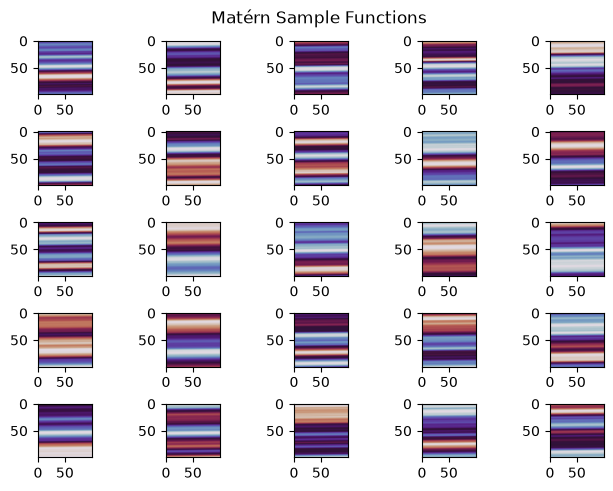

In [6]:
fig,axs = plt.subplots(5, 5, layout='constrained')
fig.suptitle('Matérn Sample Functions')
for i,ax in enumerate(axs.flat):
    ax.imshow(msample().reshape(sample_num,sample_num),cmap='twilight')
plt.show()

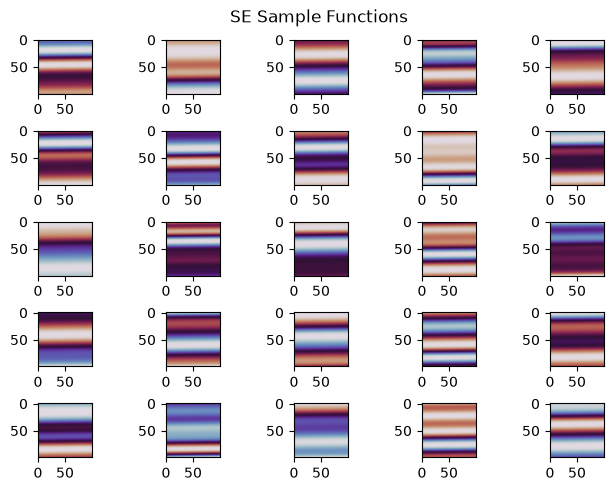

In [7]:
fig,axs = plt.subplots(5, 5, layout='constrained')
fig.suptitle('SE Sample Functions')
for i,ax in enumerate(axs.flat):
    ax.imshow(ssample().reshape(sample_num,sample_num),cmap='twilight')
plt.show()